# Lab 3: Histological image classification leveraging Bag Of Features

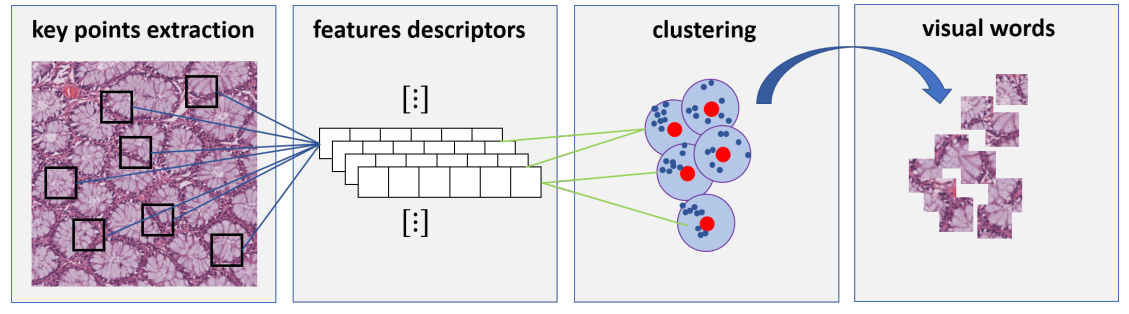

## Import and settings

In [21]:
import os
import cv2
import glob
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [22]:
!git clone https://github.com/frpnz/dataset-BIOSTEC2018.git
ROOTDIR_DATASET = "/content/dataset-BIOSTEC2018/crc_images"

fatal: destination path 'dataset-BIOSTEC2018' already exists and is not an empty directory.


## Utils
The well-know function to plot a nice confusion matrix

In [23]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")
    ax.axis("off")

Write a class to handle the dataset.
Such class must return a dict with

*   key = class
*   value = list of tuples (image, filepath)

Where image is a numpy array of shape (90, 90, 3). Hence, the images must be resized. See functions in [OpenCV-Python](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html), a library of Python bindings designed to solve computer vision problem.

In [24]:
class Dataset:
    def __init__(self, path):
        self.path = path

    def getFiles(self):
        """
        returns a dict with key = object_name and value = list of tuples (image, filepath)
        """
        image_dict = dict()
        for subdir in glob.glob(f"{self.path}/*/", recursive=False):
            word = os.path.basename(os.path.normpath(subdir))
            image_dict[word] = list()
            for image_file in glob.glob(f"{subdir}/*", recursive=False):
                image = cv2.imread(image_file, 1)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (90, 90))
                image_dict[word].append((image, image_file))
        return image_dict

In [25]:
path_train = os.path.join(ROOTDIR_DATASET, "train")
dataset = Dataset(path_train)
dataset_train = dataset.getFiles()

# Assignment #1: Plot some random images to ensure the images to be correctly loaded.
This should be their aspect.

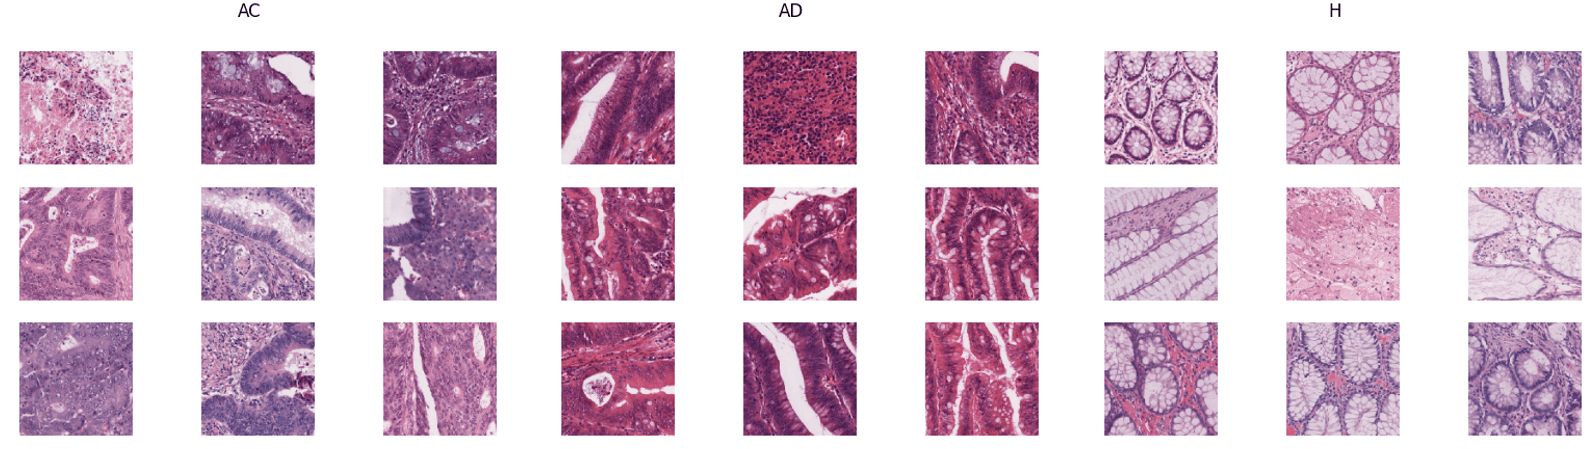

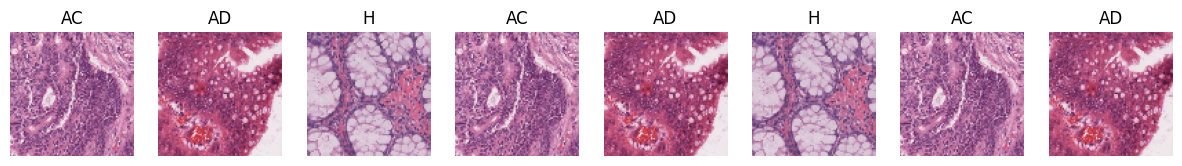

In [26]:
# Assignment 1: Plot some random images
fig, axes = plt.subplots(1, 8, figsize=(15, 3))
for i, ax in enumerate(axes):
    class_name = list(dataset_train.keys())[i % len(dataset_train)]
    img_tuple = dataset_train[class_name][0] # Get first image
    ax.imshow(img_tuple[0])
    ax.set_title(class_name)
    ax.axis('off')
plt.show()

In [27]:
class ImageHelpers:
    def __init__(self):
        self.sift_object = cv2.SIFT_create()

    def gray(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return gray

    def features(self, image):
        keypoints, descriptors = self.sift_object.detectAndCompute(image, None)
        return [keypoints, descriptors]

Extract SIFT descriptors for all the images. See an example [here](https://vovkos.github.io/doxyrest-showcase/opencv/sphinxdoc/page_tutorial_py_sift_intro.html)

Using SIFT, we detect and extract features inside each image. SIFT through OPENCV returns us a  `m x 128` dimension array, where `m` is the number of features extrapolated. Note that `m changes among different images`, depending on which features are detected. In some extreme cases (specifically when the image resolution is lower than 128x128) I experienced to get no detected features at all for some images.

In [49]:
# extract SIFT Features from each image
class Descriptors:
    def __init__(self, dataset):
        self.dataset = dataset
        self.im_helper = ImageHelpers()

    def GetDescriptors(self):
        labels = list()
        descriptor_list = list()
        name_dict = dict()
        label_count = 0
        for word, imlist in self.dataset.items():
            name_dict[label_count] = word
            for im, filepath in imlist:
                kp, des = self.im_helper.features(im)
                if des is None or des.size == 0: # Modified: Added check for empty descriptor array
                    print(f"Cannot extract SIFT for {filepath}.")
                    continue
                descriptor_list.append(des)
                labels.append(label_count)
            label_count += 1
        return descriptor_list, labels, name_dict

# Assignment #2: # reshape list into np array of shape K samples x 128 features for sklearn



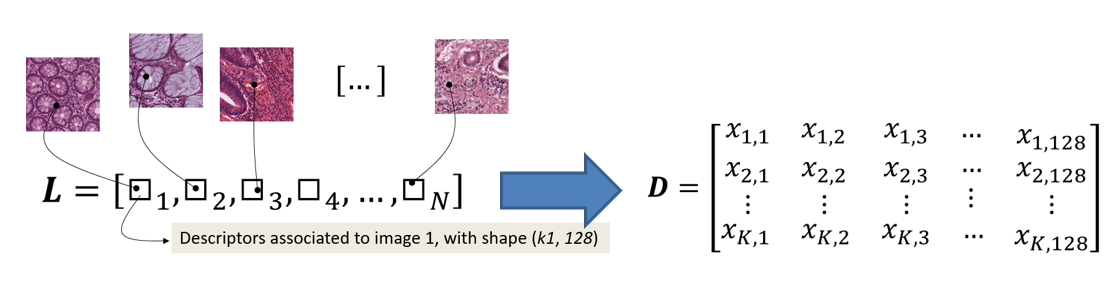

In [29]:
# 1. Initialize the Descriptors class with  training dataset
descriptors_handler = Descriptors(dataset_train)

# 2. Extract the descriptors, labels, and the dictionary mapping
# This returns the list of descriptor arrays that Assignment #2 expects
descriptors_list_train, labels_train, name_dict = descriptors_handler.GetDescriptors()

# Now vertically stack them
import numpy as np
descriptors_list_train_reshape = np.vstack(descriptors_list_train)
print("Reshaped array shape:", descriptors_list_train_reshape.shape)

Reshaped array shape: (915095, 128)


# Assignment #3: Construction of the visual vocabulary by k-means clustering (see [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) implementation)
May require some time depending on the input resolution (~ 6/7 mins for 70x70 RGB images).

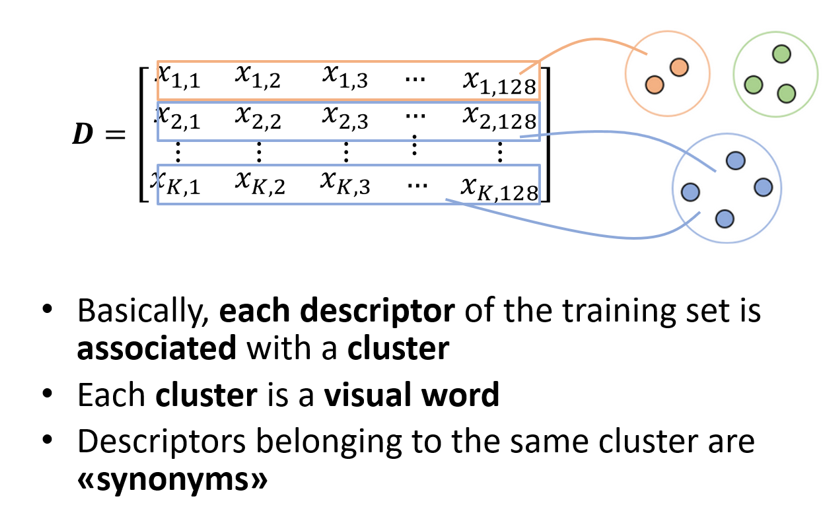

In [34]:
# Assignment #3: Construction of the visual vocabulary by k-means clustering
from sklearn.cluster import KMeans

# Define the number of visual words (clusters)
n_clusters = 20

# Initialize the KMeans model
# 'n_init' is set to 'auto' to follow modern sklearn defaults
kmeans_train = KMeans(n_clusters=n_clusters, n_init='auto')

# Fit the model on the list of descriptors and predict the cluster for each descriptor
# descriptors_list_train should be a numpy array containing all SIFT descriptors from the training set
kmeans_pred_train = kmeans_train.fit_predict(descriptors_list_train_reshape)

# Assignment #4: Build the histogram of the visual words


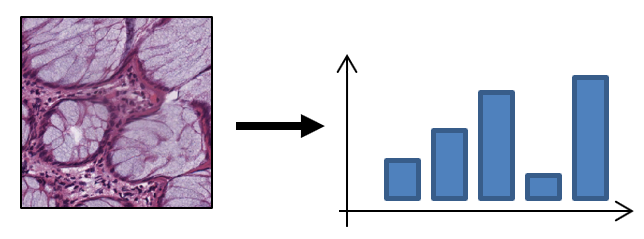

In [35]:

def MakeHistogram(descriptors_list, n_clusters, kmeans_pred):
    """
    Creates a histogram of visual words for each image.

    Args:
        descriptors_list: List of descriptors per image.
        n_clusters: Number of clusters (vocabulary size).
        kmeans_pred: Cluster predictions for all descriptors.
    """
    # Initialize the histogram matrix (Number of images x Number of clusters)
    histogram = np.zeros((len(descriptors_list), n_clusters))

    # Pointer to track our position in the flat kmeans_pred array
    idx = 0
    for i in range(len(descriptors_list)):
        # Calculate how many descriptors belong to the current image
        num_descriptors = len(descriptors_list[i])

        # Get the cluster assignments for this image's descriptors
        image_predictions = kmeans_pred[idx : idx + num_descriptors]

        # Count occurrences of each visual word (cluster)
        for word in image_predictions:
            histogram[i, word] += 1

        # Move the pointer to the next image's descriptors
        idx += num_descriptors

    return histogram



## Assignment #4.1: Scale the histogram of the visual words

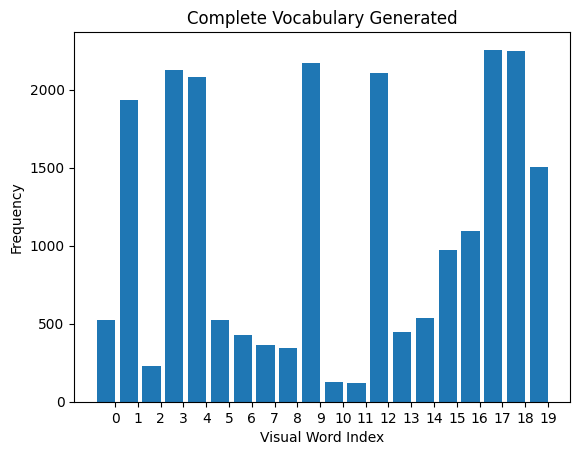

In [36]:


from sklearn.preprocessing import StandardScaler

# --- SCALING THE HISTOGRAM ---
# Create the initial training histogram using the function from Assignment #3
histogram_train = MakeHistogram(descriptors_list_train, n_clusters, kmeans_pred_train)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
histogram_train_scaled = scaler.fit_transform(histogram_train)

# --- SHOWING THE HISTOGRAM (VISUALIZATION) ---
# Define the x-axis for 20 visual words
x_scalar = np.arange(20)

# Calculate frequencies for each visual word by summing across all images
y_scalar = np.array([abs(np.sum(histogram_train_scaled[:,h], dtype=np.int32)) for h in range(20)])

# Generate the bar chart
plt.bar(x_scalar, y_scalar)
plt.xlabel("Visual Word Index")
plt.ylabel("Frequency")
plt.title("Complete Vocabulary Generated")

# Adjust the x-ticks to align with the bars
plt.xticks(x_scalar + 0.4, x_scalar)
plt.show()

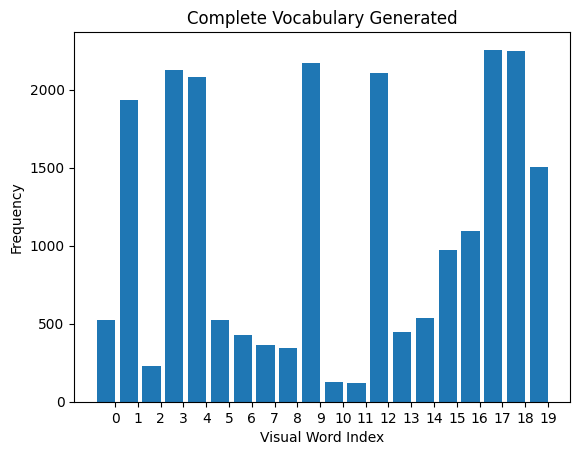

In [37]:
x_scalar = np.arange(20)
y_scalar = np.array([abs(np.sum(histogram_train_scaled[:,h], dtype=np.int32)) for h in range(20)])
plt.bar(x_scalar, y_scalar)
plt.xlabel("Visual Word Index")
plt.ylabel("Frequency")
plt.title("Complete Vocabulary Generated")
plt.xticks(x_scalar + 0.4, x_scalar)
plt.show()

# Assignment #5: Train and then test an SVM on the histogram of the visual words

In [38]:
# Initialize the SVM classifier. We can use a linear or rbf kernel.
svm_clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Define a parameter grid for RandomizedSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
}

# Perform RandomizedSearchCV
svm_random = RandomizedSearchCV(svm_clf,
                                param_distributions=param_grid,
                                n_iter=10,
                                cv=3,
                                random_state=42,
                                n_jobs=-1)

svm_random.fit(histogram_train_scaled, labels_train)

print(f"Best Parameters: {svm_random.best_params_}")

# Use the best estimator
best_svm = svm_random.best_estimator_

Best Parameters: {'gamma': 'auto', 'C': 10}


In [41]:
from sklearn.metrics import classification_report, confusion_matrix

# Use the best_svm model found by  RandomizedSearchCV
y_pred = best_svm.predict(histogram_train_scaled)


# Display final results
print("\n--- Final Evaluation Results ---")
print("Classification Report:")
print(classification_report(labels_train, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(labels_train, y_pred))


--- Final Evaluation Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      3000
           1       0.89      0.87      0.88      3000
           2       0.99      0.98      0.98      3000

    accuracy                           0.91      9000
   macro avg       0.91      0.91      0.91      9000
weighted avg       0.91      0.91      0.91      9000

Confusion Matrix:
[[2662  313   25]
 [ 382 2611    7]
 [  59    5 2936]]


## Test the model

In [42]:
path_test = os.path.join(ROOTDIR_DATASET, "test")
dataset = Dataset(path_test)
dataset_test = dataset.getFiles()

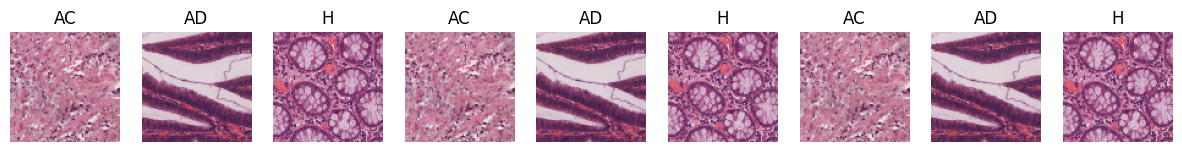

In [52]:
# Assignment 1: Plot some random images
fig, axes = plt.subplots(1, 9, figsize=(15, 3))
for i, ax in enumerate(axes):
    class_name = list(dataset_test.keys())[i % len(dataset_test)]
    img_tuple = dataset_test[class_name][0] # Get first image
    ax.imshow(img_tuple[0])
    ax.set_title(class_name)
    ax.axis('off')
plt.show()

In [44]:
# 1. Initialize the Descriptors class with  training dataset
descriptors_handler = Descriptors(dataset_test)
descriptors_list_test, labels_test, name_dict = descriptors_handler.GetDescriptors()

# Now vertically stack them
import numpy as np
descriptors_list_test_reshape = np.vstack(descriptors_list_test)
print("Reshaped array shape for test data:", descriptors_list_test_reshape.shape)

Reshaped array shape for test data: (489074, 128)


In [45]:
# Use the K-Means model (fitted on training data) to predict the cluster for each descriptor in the test set
kmeans_pred_test = kmeans_train.predict(descriptors_list_test_reshape)

In [46]:
# Create the histogram using  MakeHistogram function
# n_clusters should match  vocabulary size (e.g., 20)
histogram_test = MakeHistogram(descriptors_list_test, n_clusters, kmeans_pred_test)

# Scale the test histograms using the SAME scaler from Assignment 4.1
histogram_test_scaled = scaler.transform(histogram_test)

# --- 3. PREDICT AND EVALUATE ---
# Use the best_svm model found by RandomizedSearchCV
y_pred = best_svm.predict(histogram_test_scaled)

In [47]:

# Display final results
print("\n--- Final Evaluation Results ---")
print("Classification Report:")
print(classification_report(labels_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(labels_test, y_pred))


--- Final Evaluation Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.53      0.57      1500
           1       0.68      0.77      0.72      1500
           2       0.88      0.89      0.89      1500

    accuracy                           0.73      4500
   macro avg       0.73      0.73      0.73      4500
weighted avg       0.73      0.73      0.73      4500

Confusion Matrix:
[[ 790  526  184]
 [ 337 1161    2]
 [ 128   33 1339]]


## Full pipeline Code with curves

DEBUG: Class distribution in labels_train after SIFT filtering: Counter({np.int64(0): 3000, np.int64(1): 3000, np.int64(2): 3000})
Generating Learning Curve...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last

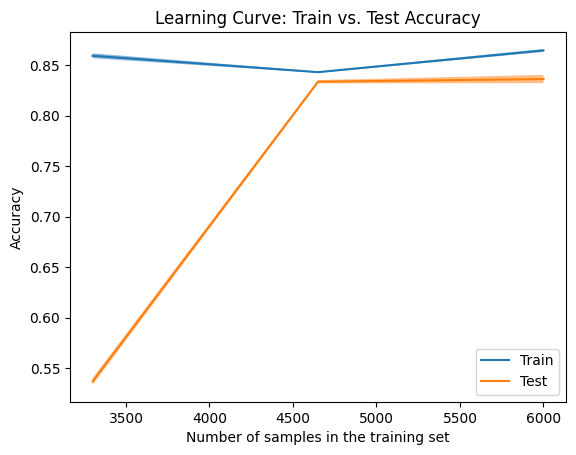

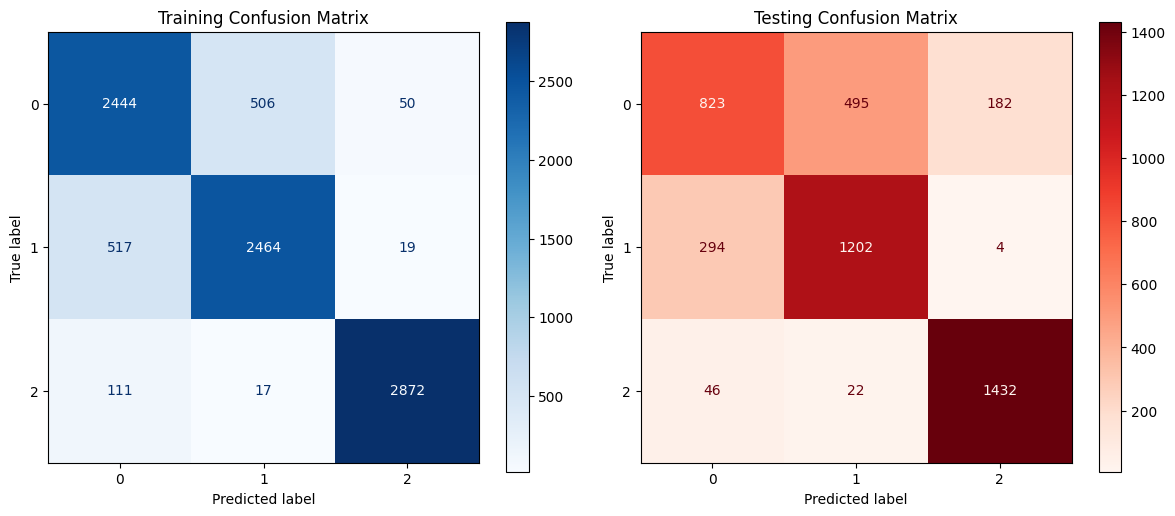


--- Final Test Evaluation ---
              precision    recall  f1-score   support

           0       0.71      0.55      0.62      1500
           1       0.70      0.80      0.75      1500
           2       0.89      0.95      0.92      1500

    accuracy                           0.77      4500
   macro avg       0.76      0.77      0.76      4500
weighted avg       0.76      0.77      0.76      4500



In [51]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, LearningCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.cluster import MiniBatchKMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
from collections import Counter # Import Counter for class distribution check

# Assuming Dataset and Descriptors classes are defined in previous cells and accessible

# ==========================================================
# 0. DATA LOADING (Separate Train and Test)
# ==========================================================
# Load data from the designated train and test directories
path_train = os.path.join(ROOTDIR_DATASET, "train")
dataset_obj_train = Dataset(path_train)
dataset_train_dict = dataset_obj_train.getFiles()

path_test = os.path.join(ROOTDIR_DATASET, "test")
dataset_obj_test = Dataset(path_test)
dataset_test_dict = dataset_obj_test.getFiles()

# ==========================================================
# 1. FEATURE EXTRACTION (SIFT) for TRAIN and TEST separately
# ==========================================================
# Extract SIFT descriptors and labels for the training set
descriptors_handler_train = Descriptors(dataset_train_dict)
descriptors_list_train, labels_train_raw, _ = descriptors_handler_train.GetDescriptors()
labels_train = np.array(labels_train_raw)

# DEBUG: Print class distribution after SIFT filtering
print(f"DEBUG: Class distribution in labels_train after SIFT filtering: {Counter(labels_train)}")

# Extract SIFT descriptors and labels for the test set
descriptors_handler_test = Descriptors(dataset_test_dict)
descriptors_list_test, labels_test_raw, _ = descriptors_handler_test.GetDescriptors()
labels_test = np.array(labels_test_raw)

# Stack all training descriptors for KMeans training (filtering out any empty ones)
all_train_descriptors = []
for des in descriptors_list_train:
    if des is not None and des.size > 0:
        all_train_descriptors.append(des)

# Check if all_train_descriptors is empty before stacking
if not all_train_descriptors:
    raise ValueError("No descriptors found in the training set. Cannot train KMeans.")

all_train_descriptors_stacked = np.vstack(all_train_descriptors)

# ==========================================================
# 2. VOCABULARY & HISTOGRAMS
# ==========================================================
n_clusters = 20
kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
kmeans.fit(all_train_descriptors_stacked) # Fit KMeans ONLY on training descriptors

# Define MakeHistogram function (optimized for this pipeline)
def MakeHistogram(descriptors_list, n_clusters, kmeans_model):
    hist = np.zeros((len(descriptors_list), n_clusters))
    for i, des in enumerate(descriptors_list):
        if des is not None and des.size > 0: # Check if descriptors are not empty
            words = kmeans_model.predict(des)
            for w in words: hist[i, w] += 1
    return hist

# Create histograms for both training and testing sets using the SAME KMeans model
histogram_train = MakeHistogram(descriptors_list_train, n_clusters, kmeans)
histogram_test = MakeHistogram(descriptors_list_test, n_clusters, kmeans)

# ==========================================================
# 3. THE PIPELINE & OPTIMIZATION
# ==========================================================
# We wrap Scaling and SVM into a single Pipeline
bof_pipe = Pipeline([
    ('scaler', StandardScaler()), # Scaler will be fitted on train_histograms and transform both train/test
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01]
}

# Use RandomizedSearch to find the best settings for the SVM
search = RandomizedSearchCV(bof_pipe, param_grid, n_iter=10, cv=3, n_jobs=-1, random_state=42)
search.fit(histogram_train, labels_train) # Fit the pipeline on training data and labels
best_model = search.best_estimator_

# ==========================================================
# 4. EVALUATION GRAPHS AND METRICS
# ==========================================================

# A. LEARNING CURVE: Compare Train vs. Test scores over data size
print("Generating Learning Curve...")
LearningCurveDisplay.from_estimator(
    best_model, histogram_train, labels_train, cv=3, scoring='accuracy'
)
plt.title("Learning Curve: Train vs. Test Accuracy")
plt.show()

# B. SIDE-BY-SIDE CONFUSION MATRICES
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Training Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_model, histogram_train, labels_train, ax=ax[0], cmap='Blues'
)
ax[0].set_title("Training Confusion Matrix")

# Testing Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_model, histogram_test, labels_test, ax=ax[1], cmap='Reds'
)
ax[1].set_title("Testing Confusion Matrix")

plt.tight_layout()
plt.show()

# C. FINAL METRICS
y_pred_test = best_model.predict(histogram_test) # Predict on the separate test set
print("\n--- Final Test Evaluation ---")
print(classification_report(labels_test, y_pred_test))